In [25]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse.linalg import eigs

# Ex 1

## 1.1

In [18]:

G = nx.Graph()

file_path = "ca-AstroPh.txt"
max_rows = 150

with open(file_path, "r") as f:
    for i, line in enumerate(f):
        if i >= max_rows:
            break
        u, v = map(int, line.strip().split())

        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
        else:
            G.add_edge(u, v, weight=1)

print("Graph loaded")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Graph loaded
Nodes: 146
Edges: 149


## 1.2

In [20]:

Ni = {}
Ei = {}
Wi = {}
lambda_w = {}

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    Ni[node] = len(neighbors)

    egonet_nodes = neighbors + [node]
    egonet = G.subgraph(egonet_nodes)

    Ei[node] = egonet.number_of_edges()

    Wi[node] = sum(
        data["weight"] for _, _, data in egonet.edges(data=True)
    )

    if egonet.number_of_nodes() > 1 and egonet.number_of_edges() > 0:
        A = nx.to_numpy_array(egonet, weight="weight")
        try:
            eigval = eigs(A, k=1, which="LM", return_eigenvectors=False)
            lambda_w[node] = np.real(eigval[0])
        except:
            lambda_w[node] = 0
    else:
        lambda_w[node] = 0

nx.set_node_attributes(G, Ni, "Ni")
nx.set_node_attributes(G, Ei, "Ei")
nx.set_node_attributes(G, Wi, "Wi")
nx.set_node_attributes(G, lambda_w, "lambda_w")

print("Features extracted")

C:\Users\maria\AppData\Local\Temp\ipykernel_8936\2511115101.py:27: RuntimeWarning: k >= N - 1 for N * N square matrix. Attempting to use scipy.linalg.eig instead.
  eigval = eigs(A, k=1, which="LM", return_eigenvectors=False)


Features extracted


## 1.3

In [21]:

nodes = list(G.nodes())
N_vals = np.array([G.nodes[n]["Ni"] for n in nodes])
E_vals = np.array([G.nodes[n]["Ei"] for n in nodes])

mask = (N_vals > 0) & (E_vals > 0)
N_vals = N_vals[mask]
E_vals = E_vals[mask]
filtered_nodes = np.array(nodes)[mask]

X = np.log(N_vals).reshape(-1, 1)
y = np.log(E_vals)

model = LinearRegression()
model.fit(X, y)

theta = model.coef_[0]
C = np.exp(model.intercept_)

scores = {}

for node, x, y_true in zip(filtered_nodes, N_vals, E_vals):
    y_pred = C * (x ** theta)
    score = (
        max(y_true, y_pred) / min(y_true, y_pred)
    ) * np.log(abs(y_true - y_pred) + 1)
    scores[node] = score

nx.set_node_attributes(G, scores, "oddball_score")

## 1.4

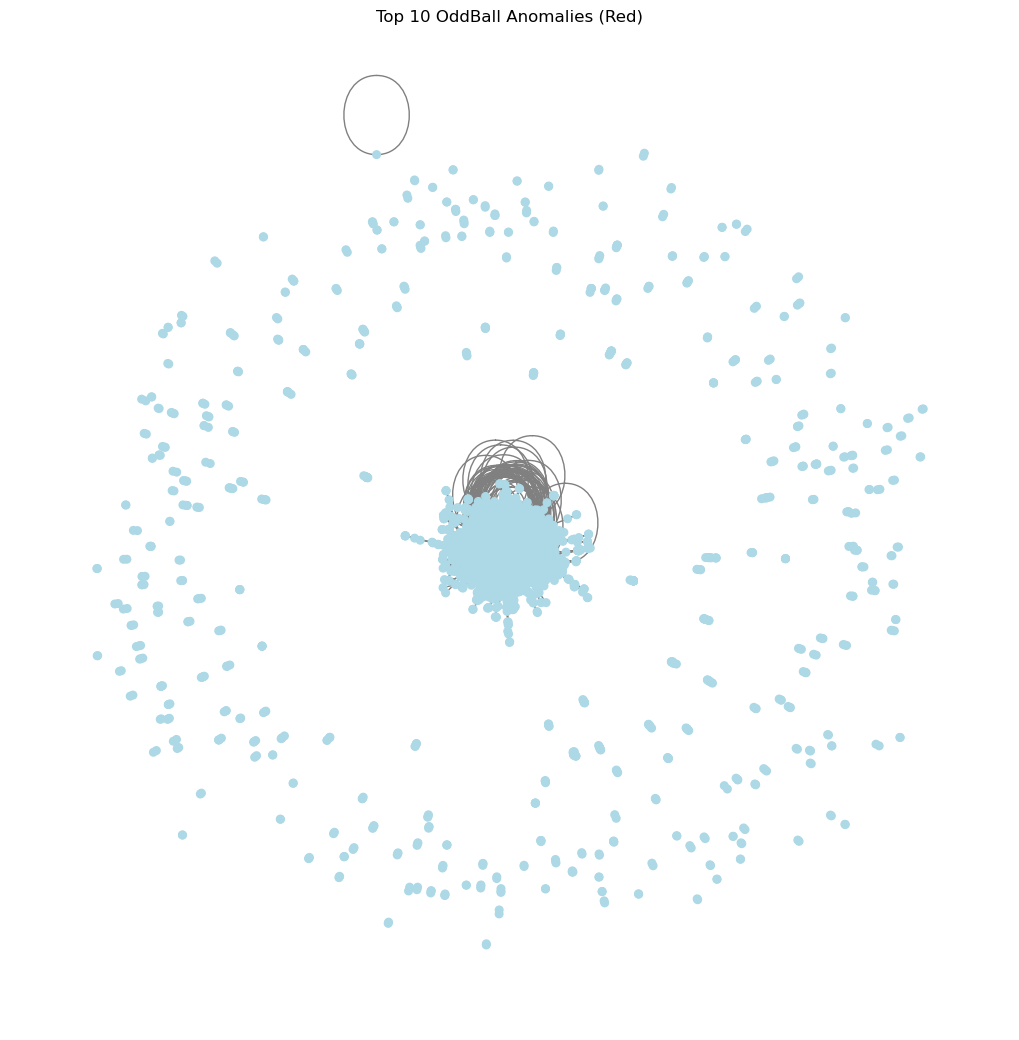

In [22]:

top10 = sorted(scores, key=scores.get, reverse=True)[:10]

node_colors = [
    "red" if n in top10 else "lightblue"
    for n in G.nodes()
]

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    node_size=30,
    node_color=node_colors,
    edge_color="gray",
    with_labels=False
)
plt.title("Top 10 OddBall Anomalies (Red)")
plt.show()


## 1.5

C:\Users\maria\anaconda3\envs\cuda\lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


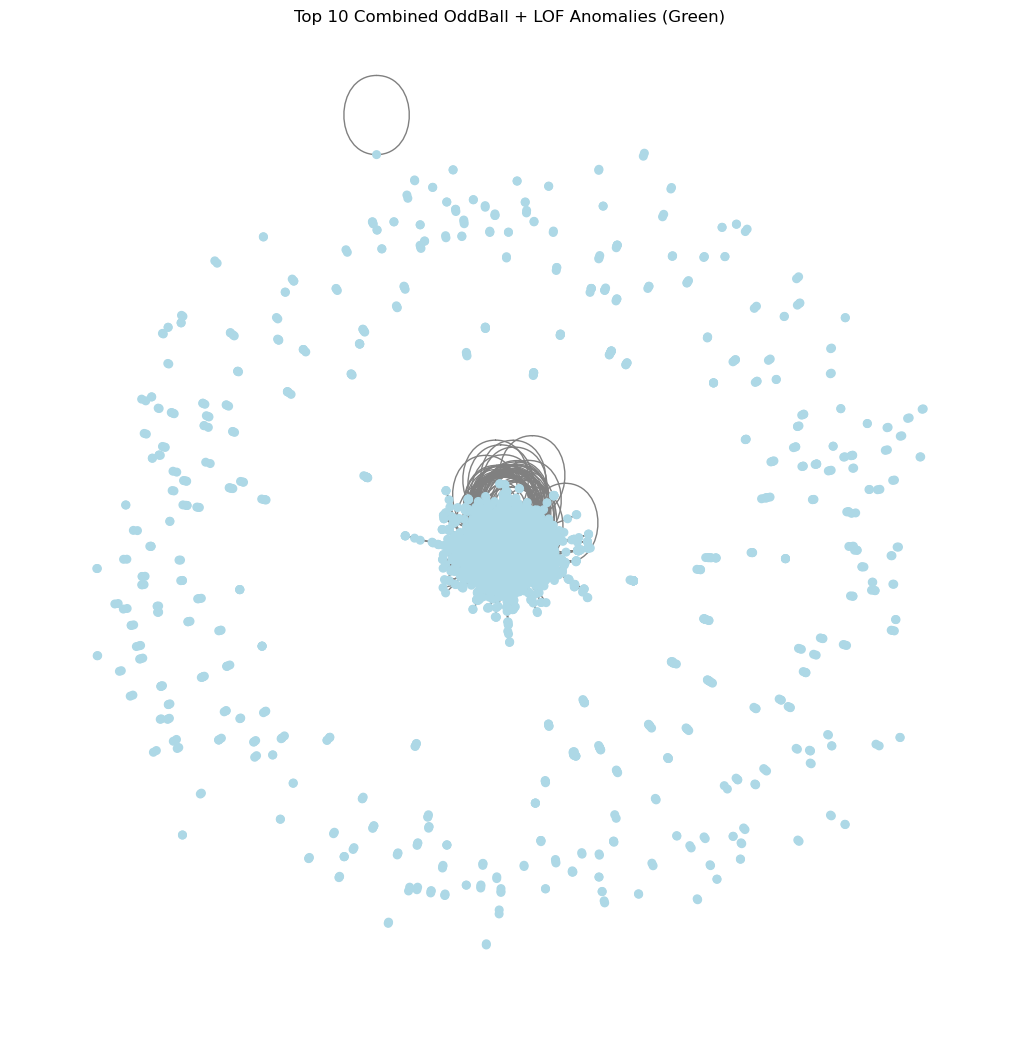

In [23]:

X_lof = np.column_stack((N_vals, E_vals))

lof = LocalOutlierFactor(n_neighbors=20)
lof_scores = -lof.fit_predict(X_lof)
lof_scores = lof.negative_outlier_factor_

scaler = MinMaxScaler()

oddball_vals = np.array([scores[n] for n in filtered_nodes]).reshape(-1, 1)
lof_vals = lof_scores.reshape(-1, 1)

oddball_norm = scaler.fit_transform(oddball_vals)
lof_norm = scaler.fit_transform(lof_vals)

combined_scores = oddball_norm.flatten() + lof_norm.flatten()

combined_dict = {
    node: score
    for node, score in zip(filtered_nodes, combined_scores)
}

nx.set_node_attributes(G, combined_dict, "combined_score")

top10_combined = sorted(
    combined_dict, key=combined_dict.get, reverse=True
)[:10]

node_colors_combined = [
    "green" if n in top10_combined else "lightblue"
    for n in G.nodes()
]

plt.figure(figsize=(10, 10))
nx.draw(
    G,
    pos,
    node_size=30,
    node_color=node_colors_combined,
    edge_color="gray",
    with_labels=False
)
plt.title("Top 10 Combined OddBall + LOF Anomalies (Green)")
plt.show()

# Ex 2

## 2.1

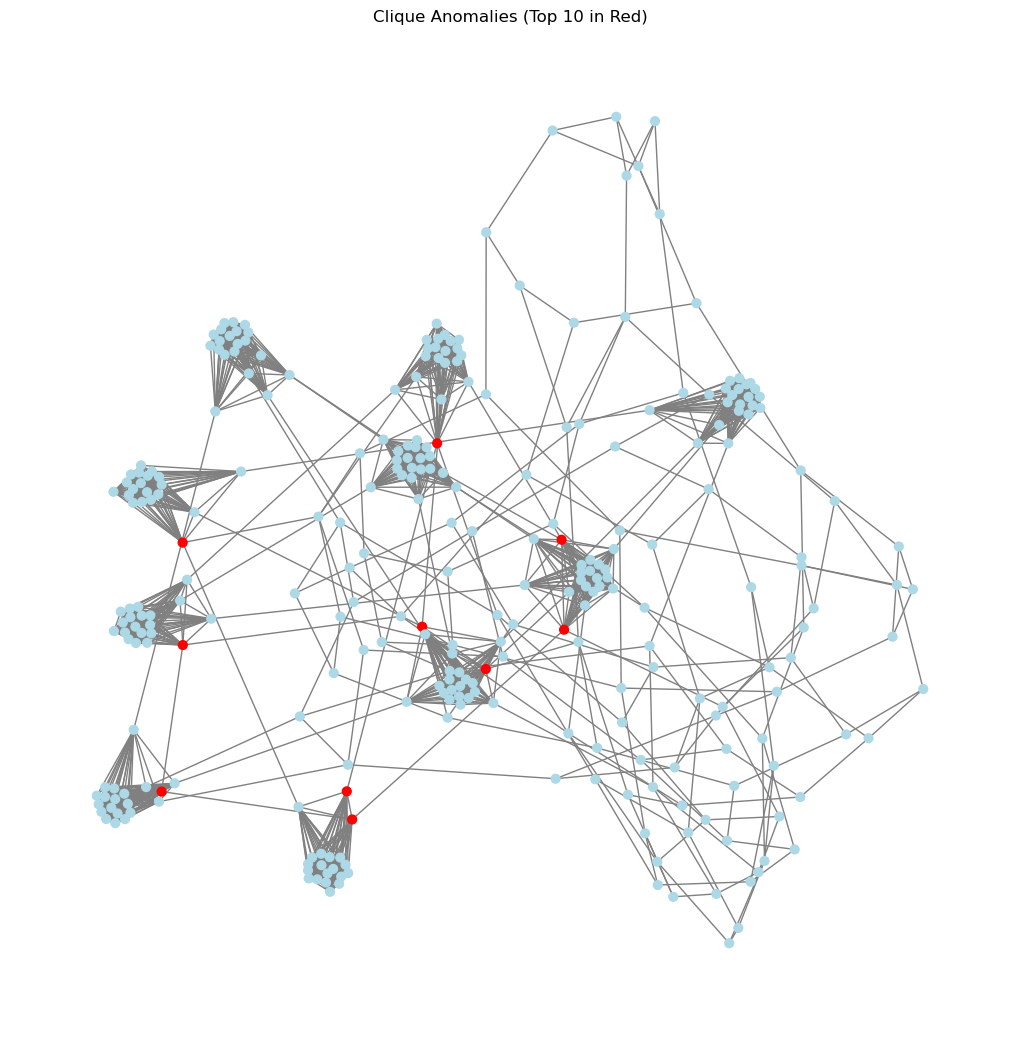

In [27]:

G_reg = nx.random_regular_graph(d=3, n=100)
G_clique = nx.connected_caveman_graph(10, 20)

G = nx.union(G_reg, G_clique, rename=("R_", "C_"))

nodes = list(G.nodes())
for _ in range(30):
    u, v = random.sample(nodes, 2)
    G.add_edge(u, v)

Ni = {}
Ei = {}

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    Ni[node] = len(neighbors)

    egonet = G.subgraph(neighbors + [node])
    Ei[node] = egonet.number_of_edges()

nx.set_node_attributes(G, Ni, "Ni")
nx.set_node_attributes(G, Ei, "Ei")


nodes = list(G.nodes())
N_vals = np.array([Ni[n] for n in nodes])
E_vals = np.array([Ei[n] for n in nodes])

mask = (N_vals > 0) & (E_vals > 0)
N_vals = N_vals[mask]
E_vals = E_vals[mask]
filtered_nodes = np.array(nodes)[mask]

X = np.log(N_vals).reshape(-1, 1)
y = np.log(E_vals)

model = LinearRegression()
model.fit(X, y)

theta = model.coef_[0]
C = np.exp(model.intercept_)

scores = {}
for node, x, y_true in zip(filtered_nodes, N_vals, E_vals):
    y_pred = C * (x ** theta)
    scores[node] = (
        max(y_true, y_pred) / min(y_true, y_pred)
    ) * np.log(abs(y_true - y_pred) + 1)

# top 10 clique anomalies
top10 = sorted(scores, key=scores.get, reverse=True)[:10]


colors = ["red" if n in top10 else "lightblue" for n in G.nodes()]

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=40, node_color=colors, edge_color="gray")
plt.title("Clique Anomalies (Top 10 in Red)")
plt.show()


## 2.2

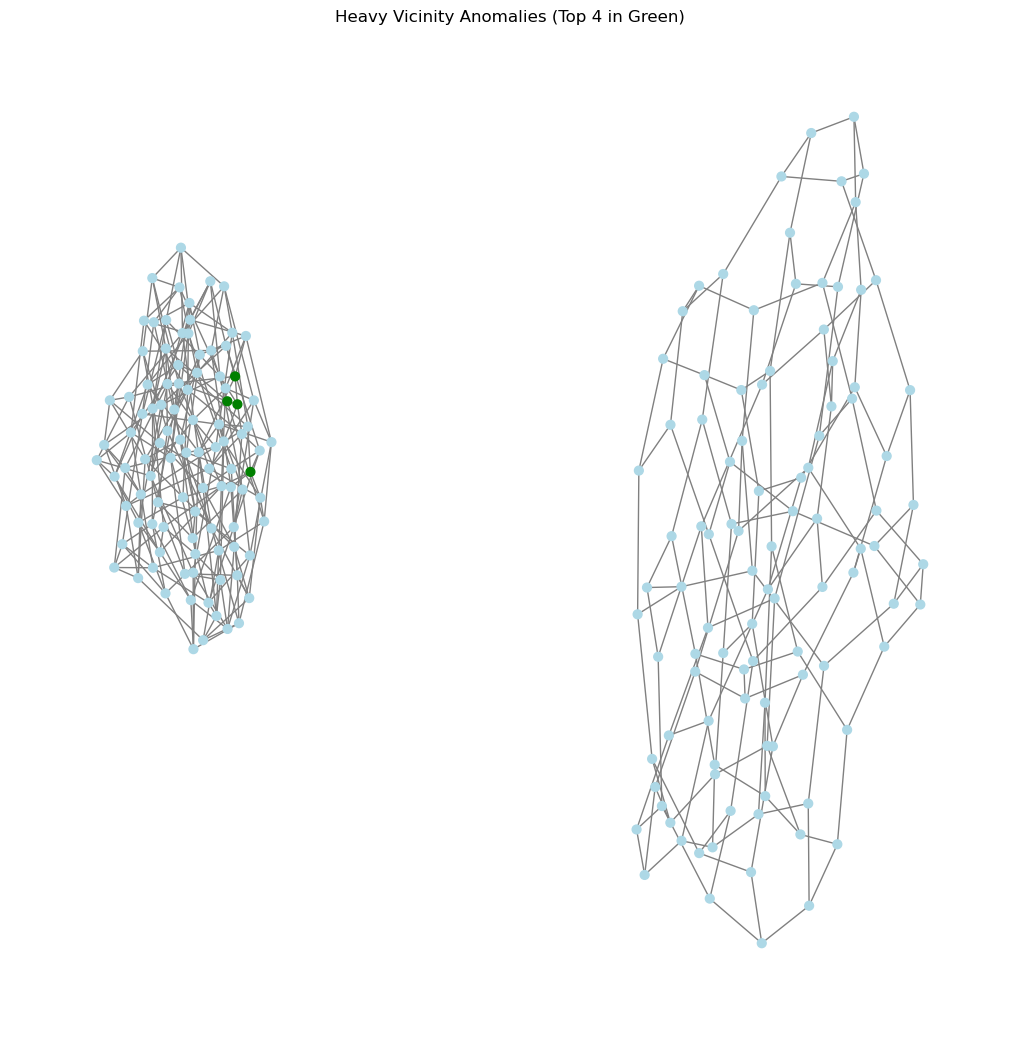

In [29]:

G1 = nx.random_regular_graph(3, 100)
G2 = nx.random_regular_graph(5, 100)

G = nx.union(G1, G2, rename=("R_", "C_"))

for u, v in G.edges():
    G[u][v]["weight"] = 1


anomaly_nodes = random.sample(list(G.nodes()), 2)

for node in anomaly_nodes:
    neighbors = list(G.neighbors(node))
    for nbr in neighbors:
        G[node][nbr]["weight"] += 10


Ei = {}
Wi = {}

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    egonet_nodes = neighbors + [node]
    egonet = G.subgraph(egonet_nodes)

    Ei[node] = egonet.number_of_edges()
    Wi[node] = sum(
        data["weight"] for _, _, data in egonet.edges(data=True)
    )

nx.set_node_attributes(G, Ei, "Ei")
nx.set_node_attributes(G, Wi, "Wi")

nodes = list(G.nodes())
E_vals = np.array([Ei[n] for n in nodes])
W_vals = np.array([Wi[n] for n in nodes])

mask = (E_vals > 0) & (W_vals > 0)
E_vals = E_vals[mask]
W_vals = W_vals[mask]
filtered_nodes = np.array(nodes)[mask]

X = np.log(E_vals).reshape(-1, 1)
y = np.log(W_vals)

model = LinearRegression()
model.fit(X, y)

theta = model.coef_[0]
C = np.exp(model.intercept_)

scores = {}
for node, x, y_true in zip(filtered_nodes, E_vals, W_vals):
    y_pred = C * (x ** theta)
    score = (
        max(y_true, y_pred) / min(y_true, y_pred)
    ) * np.log(abs(y_true - y_pred) + 1)
    scores[node] = score

# top 4 heavy vicinity anomalies
top4 = sorted(scores, key=scores.get, reverse=True)[:4]

colors = ["green" if n in top4 else "lightblue" for n in G.nodes()]

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=24)
nx.draw(G, pos, node_size=40, node_color=colors, edge_color="gray")
plt.title("Heavy Vicinity Anomalies (Top 4 in Green)")
plt.show()
